# 3.2 Clustering

Ejecutaremos una tarea de **aprendizaje no supervisado** para identificar grupos de clientes con características en común.

**¿Qué es un cluster?** Un grupo de datos que comparten características similares entre sí y que se encuentran más cercanos entre ellos en un espacio de características, en comparación con otros grupos. Permiten identificar patrones o segmentos naturales sin necesidad de etiquetas predeterminadas.

## Importar paquetes

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

## Carga de datos

In [2]:
df = pd.read_csv('./data/retailmax.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Selección de features

Usaremos las variables numéricas que mejor capturan el comportamiento del cliente: **edad**, **ingreso anual** y **puntuación de gasto**. Dejamos fuera `CustomerID` (identificador único, sin información útil) y `Gender` (categórica) por ahora.

In [3]:
features = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
features.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


### Ojo con los índices

Aunque quitamos columnas al crear `features`, **los índices se conservan** respecto a `df`. Esto será clave al final para volver a unir los clusters con el DataFrame original.

In [4]:
features.sample(5, random_state=42)

,Age,Annual Income (k$),Spending Score (1-100)
95,24,60,52
15,22,20,79
30,60,30,4
158,34,78,1
128,59,71,11


## Estandarización

Escalamos con `StandardScaler` para que cada variable tenga **media 0 y desviación estándar 1**. Así todas contribuyen de forma equitativa y ninguna domina por su rango. Esto es clave en K-Means, que se basa en distancias euclidianas.

In [5]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

### Inspección rápida

`scaled_features` es un `numpy.ndarray`, así que lo revisamos con `.shape` y por índices.

In [6]:
type(scaled_features)

numpy.ndarray

In [7]:
scaled_features.shape

(200, 3)

In [8]:
scaled_features[0:3]

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298]])

## Creación de clusters

Implementamos K-Means de Scikit-Learn. El parámetro `n_clusters` define cuántos grupos queremos. Empezamos con 5.

In [9]:
kmeans = KMeans(n_clusters=5, init='k-means++', max_iter=300, n_init=10, random_state=42)
clusters = kmeans.fit_predict(scaled_features)
clusters

array([1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 4, 1, 0, 1,
       0, 1, 4, 1, 1, 1, 4, 1, 1, 4, 4, 4, 4, 4, 1, 4, 4, 1, 4, 4, 4, 1,
       4, 4, 1, 1, 4, 4, 4, 4, 4, 1, 4, 4, 1, 4, 4, 1, 4, 4, 1, 4, 4, 1,
       1, 4, 4, 1, 4, 4, 1, 1, 4, 1, 4, 1, 1, 4, 4, 1, 4, 1, 4, 4, 4, 4,
       4, 1, 3, 1, 1, 1, 4, 4, 4, 4, 1, 3, 2, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 4, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2], dtype=int32)

Cada número del array representa el cluster asignado a cada cliente. Como **no alteramos el orden** de las filas, podemos "pegar" este array como una nueva columna en `df`.

In [10]:
df['Cluster'] = clusters
df.sample(5, random_state=42)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
95,96,Male,24,60,52,1
15,16,Male,22,20,79,1
30,31,Male,60,30,4,0
158,159,Male,34,78,1,3
128,129,Male,59,71,11,3


## Visualización de clusters

Ingreso anual en el eje X y puntuación de gasto en el eje Y.

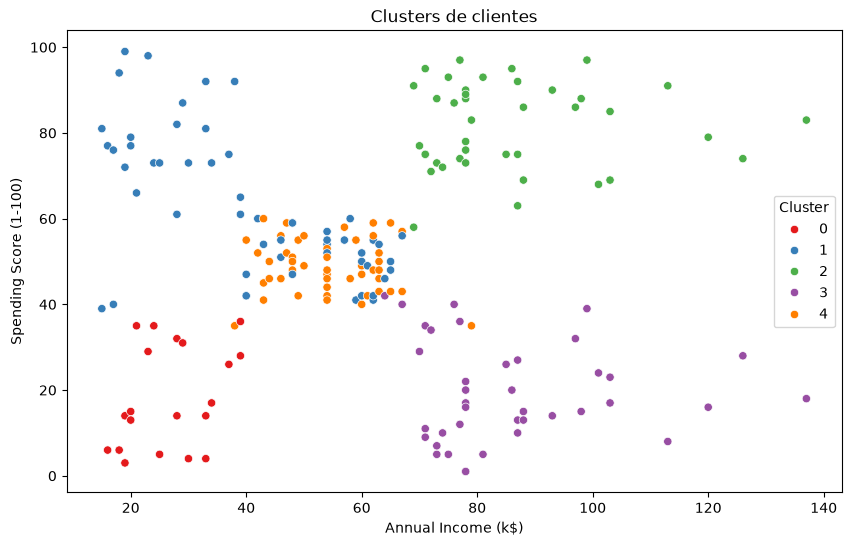

In [11]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', palette='Set1')
plt.title('Clusters de clientes')
plt.show()

## Optimización: el método del codo (Elbow Method)

¿Cuál es el número óptimo de clusters? El método del codo ejecuta K-Means con distintos valores de `k` y grafica la **inercia (WCSS)** frente al número de clusters. El "codo", donde la curva pasa de bajar rápido a bajar lento, indica el número adecuado.

**WCSS** (Within-Cluster Sum of Squares): suma de las distancias cuadradas de cada punto al centroide de su cluster.

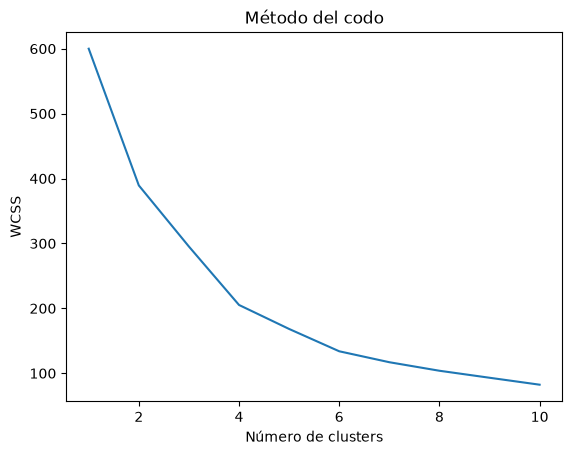

In [12]:
# Función para calcular la Suma de Cuadrados Dentro del Cluster (WCSS)
def calcular_wcss(datos):
    wcss = []
    for n in range(1, 11):
        kmeans = KMeans(n_clusters=n, init='k-means++', max_iter=300, n_init=10, random_state=42)
        kmeans.fit(datos)
        wcss.append(kmeans.inertia_)
    return wcss

# Calcular el WCSS para diferentes números de clusters
wcss = calcular_wcss(scaled_features)

# Graficar el método del codo
plt.plot(range(1, 11), wcss)
plt.title('Método del codo')
plt.xlabel('Número de clusters')
plt.ylabel('WCSS')
plt.show()

Según el codo, un número adecuado de clusters es **5 o 6**. Ajustamos el modelo definitivo con 5 clusters.

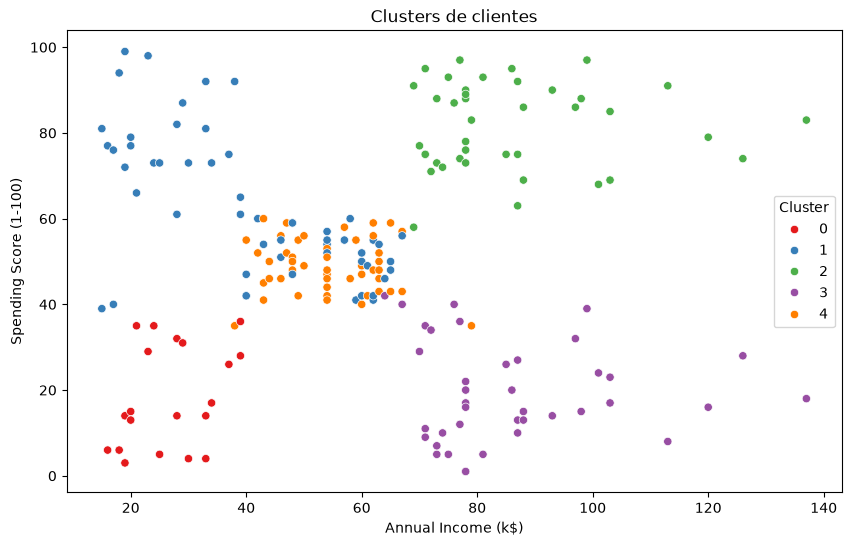

In [13]:
kmeans = KMeans(n_clusters=5, init='k-means++', max_iter=300, n_init=10, random_state=42)
clusters = kmeans.fit_predict(scaled_features)
df['Cluster'] = clusters

# mostrar gráfica
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', palette='Set1')
plt.title('Clusters de clientes')
plt.show()

## Visualización 3D

Como también tenemos la edad, podemos ver los clusters en 3 dimensiones.

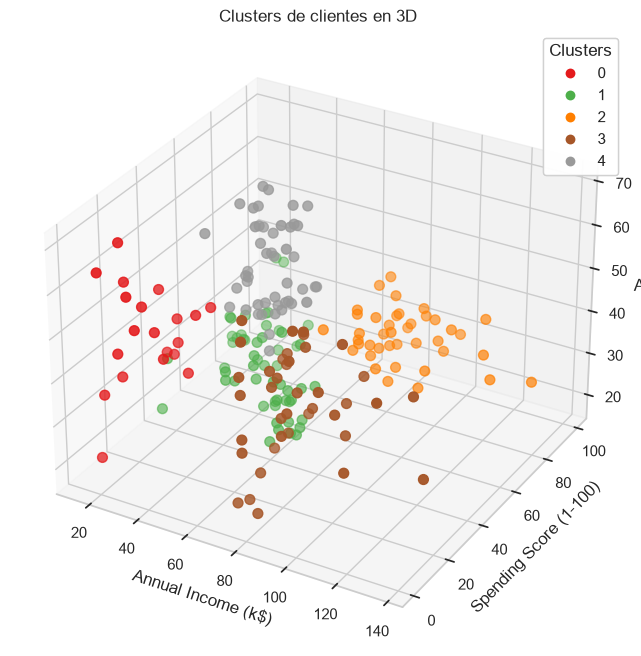

In [14]:
from mpl_toolkits.mplot3d import Axes3D

# Configurar el estilo de Seaborn
sns.set(style='whitegrid')

# Crear una figura en 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Gráfico 3D de dispersión
scatter = ax.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], df['Age'],
                     c=df['Cluster'], cmap='Set1', s=50)

# Etiquetas de los ejes
ax.set_xlabel('Annual Income (k$)')
ax.set_ylabel('Spending Score (1-100)')
ax.set_zlabel('Age')

# Título de la gráfica
ax.set_title('Clusters de clientes en 3D')

# Añadir la leyenda
legend1 = ax.legend(*scatter.legend_elements(), title='Clusters')
ax.add_artist(legend1)

plt.show()

## Análisis final

Analizamos el contenido de cada cluster (promedios) para poder hacer recomendaciones.

In [15]:
cluster_analysis = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Cluster']].groupby('Cluster').mean()
cluster_analysis

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,46.250000,26.750000,18.350000
1,25.185185,41.092593,62.240741
2,32.875000,86.100000,81.525000
3,39.871795,86.102564,19.358974
4,55.638298,54.382979,48.851064


In [16]:
for cluster in cluster_analysis.index:
    print(f"Cluster {cluster}:")
    print(f" - Edad media: {cluster_analysis['Age'][cluster]:.2f}")
    print(f" - Ingreso anual medio: {cluster_analysis['Annual Income (k$)'][cluster]:.2f}k$")
    print(f" - Calificación RetailMax: {cluster_analysis['Spending Score (1-100)'][cluster]:.2f}")
    print("===========================================")

Cluster 0:
 - Edad media: 46.25
 - Ingreso anual medio: 26.75k$
 - Calificación RetailMax: 18.35
Cluster 1:
 - Edad media: 25.19
 - Ingreso anual medio: 41.09k$
 - Calificación RetailMax: 62.24
Cluster 2:
 - Edad media: 32.88
 - Ingreso anual medio: 86.10k$
 - Calificación RetailMax: 81.53
Cluster 3:
 - Edad media: 39.87
 - Ingreso anual medio: 86.10k$
 - Calificación RetailMax: 19.36
Cluster 4:
 - Edad media: 55.64
 - Ingreso anual medio: 54.38k$
 - Calificación RetailMax: 48.85


## Incorporando la variable "sexo"

Antes dejamos fuera el género para evitar la variable categórica. Ahora la convertimos a numérica (`Male`=0, `Female`=1) y la incluimos. Como `Female`=1, el promedio de `Gender` por cluster representa la **proporción de mujeres**.

In [17]:
# Convertir a numérica
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

# selección de features
extended_features = df[['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# estandarización
scaled_extended_features = scaler.fit_transform(extended_features)

# Aplicar K-Means
kmeans = KMeans(n_clusters=5, init='k-means++', max_iter=300, n_init=10, random_state=42)
clusters_extended = kmeans.fit_predict(scaled_extended_features)

# Sustituir clusters anteriores
df['Cluster'] = clusters_extended

# análisis
extended_cluster_analysis = df[['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Cluster']].groupby('Cluster').mean()
extended_cluster_analysis

,Gender,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,0.538462,32.692308,86.538462,82.128205
1,0.551724,36.482759,89.517241,18.000000
2,1.000000,49.813953,49.232558,40.069767
3,0.592593,24.907407,39.722222,61.203704
4,0.000000,55.714286,53.685714,36.771429


In [18]:
for cluster in extended_cluster_analysis.index:
    print(f"Cluster {cluster}:")
    print(f" - Edad promedio: {extended_cluster_analysis['Age'][cluster]:.2f}")
    print(f" - Ingreso anual promedio: {extended_cluster_analysis['Annual Income (k$)'][cluster]:.2f}k$")
    print(f" - Calificación RetailMax promedio: {extended_cluster_analysis['Spending Score (1-100)'][cluster]:.2f}")
    print(f" - % mujeres: {extended_cluster_analysis['Gender'][cluster]*100:.2f}%")
    print("===========================================")

Cluster 0:
 - Edad promedio: 32.69
 - Ingreso anual promedio: 86.54k$
 - Calificación RetailMax promedio: 82.13
 - % mujeres: 53.85%
Cluster 1:
 - Edad promedio: 36.48
 - Ingreso anual promedio: 89.52k$
 - Calificación RetailMax promedio: 18.00
 - % mujeres: 55.17%
Cluster 2:
 - Edad promedio: 49.81
 - Ingreso anual promedio: 49.23k$
 - Calificación RetailMax promedio: 40.07
 - % mujeres: 100.00%
Cluster 3:
 - Edad promedio: 24.91
 - Ingreso anual promedio: 39.72k$
 - Calificación RetailMax promedio: 61.20
 - % mujeres: 59.26%
Cluster 4:
 - Edad promedio: 55.71
 - Ingreso anual promedio: 53.69k$
 - Calificación RetailMax promedio: 36.77
 - % mujeres: 0.00%
